HR Analytics – Employee Attrition Analysis

The goal of this project is to analyze employee data and identify factors that contribute to employee attrition.

Using Python data analysis tools such as Pandas, Seaborn, and Matplotlib, we explore patterns in employee satisfaction, workload, salary levels, and department distribution to understand why employees leave the organization.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/employe.csv")

In [ ]:
df.sample(10)

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
6935,0.69,0.80,3,212,4,0,0,0,support,low
7052,0.61,0.75,3,140,3,0,0,0,RandD,low
14736,1.00,0.87,4,129,5,0,0,0,support,medium
7956,0.52,0.55,5,174,3,1,0,0,sales,medium
5226,0.13,0.52,6,188,3,0,0,0,sales,medium
5679,0.68,0.85,4,203,2,0,0,0,technical,low
14205,0.74,0.67,3,273,3,1,0,0,hr,low
5263,0.32,0.42,6,114,3,0,0,0,product_mng,medium
2954,0.71,0.62,4,192,4,0,0,0,sales,medium
11195,0.91,0.61,4,176,3,0,0,0,sales,low


In [ ]:
df.columns


Index(['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpent.company', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='object')

In [ ]:
df['numberOfProjects'].unique()

array([2, 5, 7, 6, 4, 3])

In [ ]:
df['numberOfProjects'].value_counts()

,count
numberOfProjects,
4,4365
3,4055
5,2761
2,2388
6,1174
7,256


In [ ]:
df['workAccident'].value_counts()

,count
workAccident,
0,12830
1,2169


In [ ]:
df['promotionInLast5years'].value_counts()

,count
promotionInLast5years,
0,14680
1,319


In [ ]:
df['dept'].value_counts()

,count
dept,
sales,4140
technical,2720
support,2229
IT,1227
product_mng,902
marketing,858
RandD,787
accounting,767
hr,739


In [ ]:
df['salary'].value_counts()

,count
salary,
low,7316
medium,6446
high,1237


In [ ]:
# from prompt_toolkit.filters import completion_is_selected

# 1.*satisfactory level* :- shows how much employees are satisfied with the workplace and work they are doing there on the scale of 0-1
# *possibility :-* if the satisfactory level is low the chances of attrition are high

# 2. lastevalutaion :- shows last performance score of the employee on the scale of 0-1
# possibility :- employee with less evaluation may leave or the employee with high evalutaion but less salary hikes may leave too

# 3. numberOfProjects :- shows how many projects employee is working on
# possibility :- employee with less projects may feel undervalued and employees with more may feel more workload

# 4. avgmonthlyHours :- how much time on an average employee is working
# possibility :- more working hours = more work load , less working hour = under valued

# 5. timeSpent.Company :- how much year months did the employee spent in the company
# possibility :-if employee spents more time with company and didn't get hikes then employee can leave , if they are fresher they may continue looking for some experience

# 6. workAccident :- any work accident that took place during working of the employee
# possibility :- if yes then high chances of  leaving the company , else the employee will continue with the company .

# 7. promotionInLast5Years :- if employee got any promotion in last 5 year or not ( 0 means 'NO" & 1 means 'YES')
# possibility :- if employee is staying too long with company along with good performance promotion must be granted so that employee will not leave .

# 8. dept :- various different departments of the company from where the data is collected

# 9. salary :- it defines the range of salary employees are getting (low - medium - high)
# possibility :-people getting low salary may leave , medium salary getting employee may look up for hikes or leave , high salary getting employee may stick to job or look for higher salary .


In [ ]:
df.isnull().sum()

,0
satisfactoryLevel,0
lastEvaluation,0
numberOfProjects,0
avgMonthlyHours,0
timeSpent.company,0
workAccident,0
left,0
promotionInLast5years,0
dept,0
salary,0


In [ ]:
df.duplicated().sum()

np.int64(3008)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(11991, 10)

EXPLORATORY DATA ANALYSIS



In [ ]:
df

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.11,0.85,7,275,4,0,1,0,support,medium
14995,0.99,0.83,4,274,2,0,0,0,sales,low
14996,0.72,0.72,4,175,4,0,0,0,technical,low
14997,0.24,0.91,5,177,5,0,0,0,sales,low


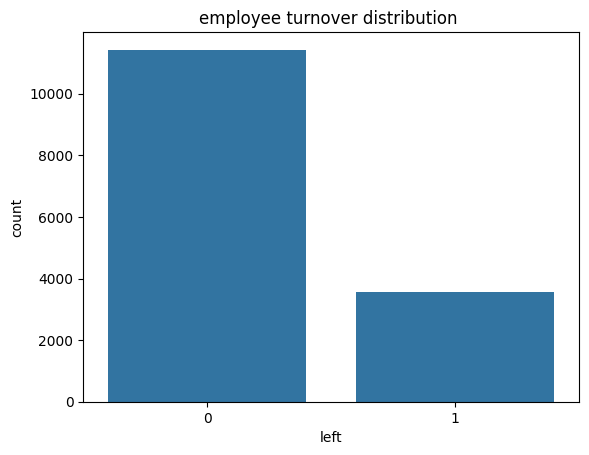

In [ ]:
# chart to show employee turnover distribution
sns.countplot(x='left', data=df )
plt.title('employee turnover distribution ')
plt.show()

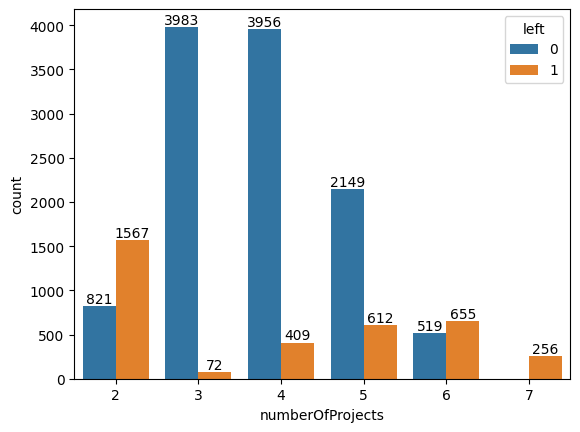

In [ ]:
#number of projects and attrition
x1= sns.countplot(x='numberOfProjects', data=df , hue='left')
x1.bar_label(x1.containers[0])
x1.bar_label(x1.containers[1])
plt.show()

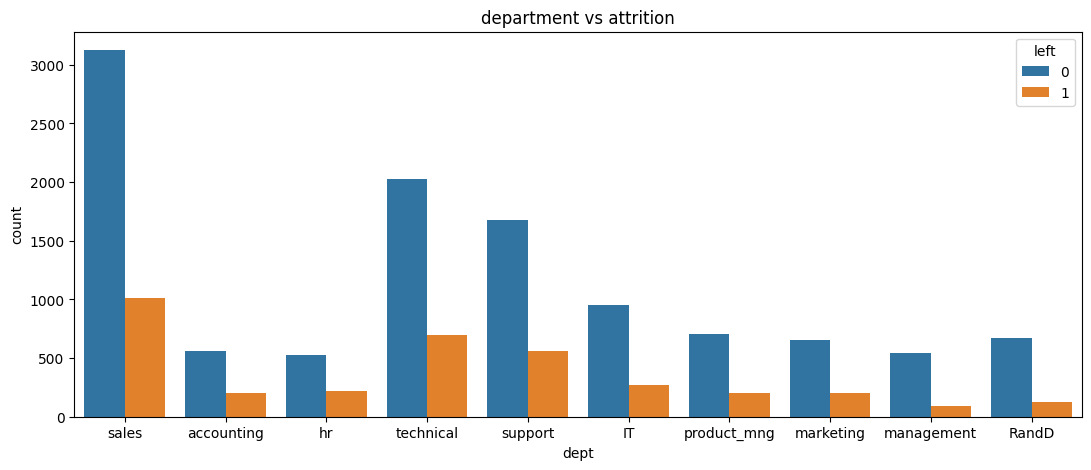

In [ ]:
#Department vs attrition
plt.figure(figsize=(13,5))
sns.countplot(x='dept',data=df , hue='left')
plt.title('department vs attrition')
plt.show()

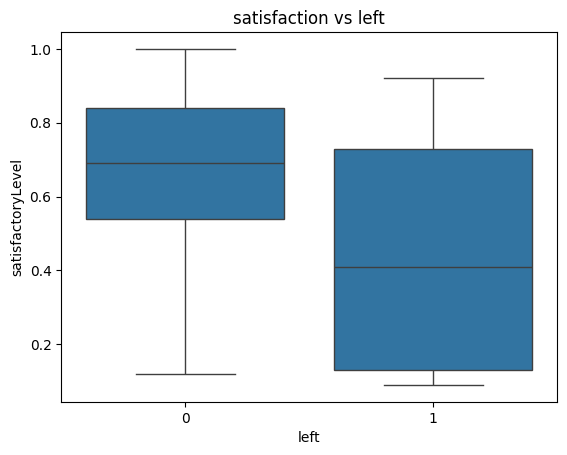

In [ ]:
# satisfaction vs leave
sns.boxplot(x='left',y='satisfactoryLevel',data=df)
plt.title('satisfaction vs left')
plt.show()

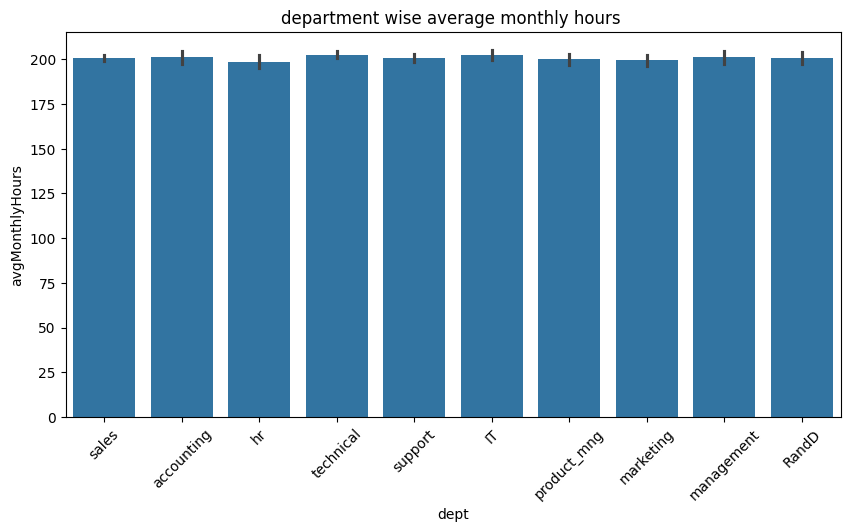

In [ ]:
#department wise average monthly hours
plt.figure(figsize=(10,5))
sns.barplot(x='dept',y='avgMonthlyHours', data=df )
plt.xticks(rotation=45)
plt.title('department wise average monthly hours ')
plt.show()

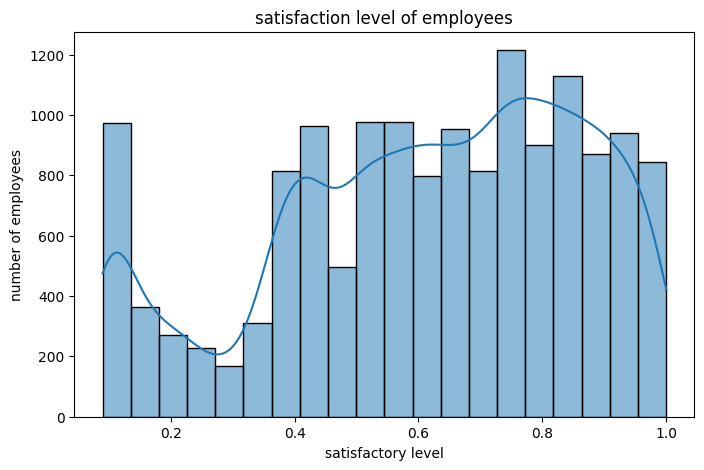

In [ ]:
#satisfaction level of employees
plt.figure(figsize=(8,5))
sns.histplot(df['satisfactoryLevel'],bins=20, kde=True)
plt.title('satisfaction level of employees')
plt.xlabel('satisfactory level')
plt.ylabel('number of employees')
plt.show()

In [ ]:
Key Findings from HR Analytics:

1. Employees with lower satisfaction levels are more likely to leave the company.
2. Employees working extreme monthly hours tend to have higher attrition.
3. Departments show varying attrition patterns indicating workload imbalance.
4. Salary level may influence employee retention.

These insights can help organizations design better employee engagement and retention strategies.
